# 08 — ViT-S/16 Baseline: Training, Evaluation & Error Analysis

This notebook implements the **Vision Transformer (ViT-S/16) baseline** for the RSNA knee MRI multi-label classification task.

The experimental protocol is intentionally matched to Notebook 07:
- same 2.5D input (`previous / current / next` slices);
- same study-level labels and study-level cross-validation;
- same mean pooling of instance logits;
- same class-weighted BCE loss;
- same evaluation metrics, plots and error-analysis outputs.

**Experiment mode:** `SMOKE_TEST=True` is only for pipeline validation. The final experiment uses all 58 gold-labelled studies with the corrected study-level folds from Notebook 05.

In [1]:
# ==================================================
# 01 — Startup / configuration
# ==================================================

import os
import gc
import glob
import random
import warnings
import subprocess
import sys
from functools import lru_cache

print("[1/4] Loading NumPy/Pandas...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("      OK")

print("[2/4] Loading PyTorch...")
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print(f"      PyTorch {torch.__version__} OK")

print("[3/4] Loading timm...")
try:
    import timm
except ImportError:
    print("      timm is not installed; attempting one-time installation...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm
print(f"      timm {timm.__version__} OK")

print("[4/4] Setting configuration...")
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IMAGE_SIZE = 224
NUM_CLASSES = 12
N_FOLDS = 5

# --------------------------------------------------
# Experiment mode
# --------------------------------------------------

SMOKE_TEST = False
SMOKE_GOLD_LIMIT = 5

# --------------------------------------------------
# Training configuration
# --------------------------------------------------

EPOCHS = 3
STUDY_BATCH_SIZE = 1

MAX_TRAIN_INSTANCES = 24
MAX_VAL_INSTANCES = 48

INSTANCE_BATCH_SIZE = 8
NUM_WORKERS = 0

FREEZE_BACKBONE = True

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

CLASSIFICATION_THRESHOLD = 0.50
MODEL_SELECTION_METRIC = "val_loss"

# --------------------------------------------------
# ViT-S/16
# --------------------------------------------------

MODEL_NAME = "vit_small_patch16_224"
PRETRAINED = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Model:", MODEL_NAME)
print("Pretrained:", PRETRAINED)
print("Smoke test:", SMOKE_TEST)
print("Startup complete.")


[1/4] Loading NumPy/Pandas...
      OK
[2/4] Loading PyTorch...
      PyTorch 2.11.0+cu128 OK
[3/4] Loading timm...
      timm 1.0.29 OK
[4/4] Setting configuration...
Device: cuda
GPU: Tesla T4
Model: vit_small_patch16_224
Pretrained: True
Smoke test: False
Startup complete.


## 2. Data and fold setup

Notebook 08 consumes the same shared artifacts as Notebook 07:

**03:** preprocessed MRI volumes → `.npy`  
**04:** neighbouring-slice 2.5D index  
**05:** study-level CV folds

Only complete gold-labelled studies are used for this supervised baseline. The fold assignment is attached at the **study level**, so slices or series from one study cannot leak across folds.


In [2]:
# ==================================================
# 02 — Dataset / artifact discovery
# ==================================================

SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]

PRUNE_DIRS = {
    "processed_data",
    "train_images",
    "test_images",
    "train_series",
    "test_series",
    "__pycache__",
    ".git"
}

def find_all(filename, max_matches=20):
    matches = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            dirs[:] = [
                d for d in dirs
                if d not in PRUNE_DIRS
            ]

            if filename in files:
                matches.append(
                    os.path.join(current, filename)
                )

                if len(matches) >= max_matches:
                    return sorted(set(matches))

    return sorted(set(matches))


def find_processed_roots():
    roots = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            keep = []

            for d in dirs:
                full = os.path.join(current, d)

                if d == "processed_data":
                    roots.append(full)
                else:
                    keep.append(d)

            dirs[:] = [
                d for d in keep
                if d not in {
                    "train_images",
                    "test_images",
                    "train_series",
                    "test_series",
                    "__pycache__",
                    ".git"
                }
            ]

    return sorted(
        set(
            os.path.normpath(p)
            for p in roots
            if os.path.isdir(p)
        )
    )


def choose_artifact(filename, preferred_tokens=()):
    candidates = find_all(filename)

    if not candidates:
        return None

    for token in preferred_tokens:
        token = token.lower()

        for path in candidates:
            if token in path.lower():
                return path

    return candidates[0]


competition_candidates = find_all("train.csv")

competition_candidates = [
    p for p in competition_candidates
    if "rsna" in p.lower()
    and "knee" in p.lower()
]

if not competition_candidates:
    generic_train = find_all("train.csv")

    if generic_train:
        competition_candidates = generic_train

if not competition_candidates:
    raise FileNotFoundError(
        "RSNA train.csv not found. "
        "Attach the RSNA Knee Abnormality Detection dataset."
    )

COMP_DIR = os.path.dirname(
    competition_candidates[0]
)

p2d_path = choose_artifact(
    "2p5d_index.csv",
    preferred_tokens=(
        "04_2.5d",
        "04-2.5d",
        "04_2p5d",
        "04-2p5d"
    )
)

if p2d_path is None:
    raise FileNotFoundError(
        "2p5d_index.csv not found. "
        "Attach Notebook 04 output."
    )

cv_index_path = choose_artifact(
    "2p5d_index_with_folds.csv",
    preferred_tokens=(
        "05_cv_splits",
        "05-cv-splits",
        "05_cv",
        "05-cv"
    )
)

if cv_index_path is None:
    raise FileNotFoundError(
        "2p5d_index_with_folds.csv not found. "
        "Attach Notebook 05 output."
    )

cv_path = choose_artifact(
    "cv_folds.csv",
    preferred_tokens=(
        "05_cv_splits",
        "05-cv-splits",
        "05_cv",
        "05-cv"
    )
)

processed_roots = find_processed_roots()

prep_metadata_candidates = find_all(
    "processed_metadata.csv"
)

prep_metadata_path = (
    prep_metadata_candidates[0]
    if prep_metadata_candidates
    else None
)

print("\nCompetition directory:")
print(COMP_DIR)

print("\nNotebook 04 2.5D index:")
print(p2d_path)

print("\nNotebook 05 2.5D + folds:")
print(cv_index_path)

print("\nNotebook 05 folds:")
print(
    cv_path
    if cv_path
    else "Derived from combined index"
)

print("\nMounted processed_data directories:")

if processed_roots:
    for p in processed_roots:
        print(p)
else:
    print("NONE FOUND")

print("\nNotebook 03 processed_metadata.csv:")
print(
    prep_metadata_path
    if prep_metadata_path
    else "OPTIONAL / NOT FOUND"
)



Competition directory:
/kaggle/input/competitions/rsna-knee-abnormality-detection

Notebook 04 2.5D index:
/kaggle/input/notebooks/shambhavisinha254/04-2-5d/2p5d_index.csv

Notebook 05 2.5D + folds:
/kaggle/input/notebooks/shambhavisinha254/05-cv-splits/2p5d_index_with_folds.csv

Notebook 05 folds:
/kaggle/input/notebooks/shambhavisinha254/05-cv-splits/cv_folds.csv

Mounted processed_data directories:
/kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data

Notebook 03 processed_metadata.csv:
/kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_metadata.csv


In [3]:
# ==================================================
# 03 — Load labels, 2.5D index and folds
# ==================================================

train = pd.read_csv(
    os.path.join(
        COMP_DIR,
        "train.csv"
    )
)

index_2p5d = pd.read_csv(
    cv_index_path
)

if cv_path is not None:
    cv_folds = pd.read_csv(cv_path)

else:
    if "fold" not in index_2p5d.columns:
        raise RuntimeError(
            "cv_folds.csv is missing and the combined "
            "2.5D artifact has no 'fold' column."
        )

    cv_folds = (
        index_2p5d[
            [
                "StudyInstanceUID",
                "fold"
            ]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

LABEL_COLS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

print("Total train studies:", len(train))
print("CV fold rows:", len(cv_folds))
print("2.5D rows:", len(index_2p5d))
print(
    "CV studies:",
    cv_folds["StudyInstanceUID"].nunique()
)
print(
    "2.5D studies:",
    index_2p5d["StudyInstanceUID"].nunique()
)


Total train studies: 4407
CV fold rows: 58
2.5D rows: 10528
CV studies: 58
2.5D studies: 58


Complete gold studies: 58
Gold studies present in CV: 58


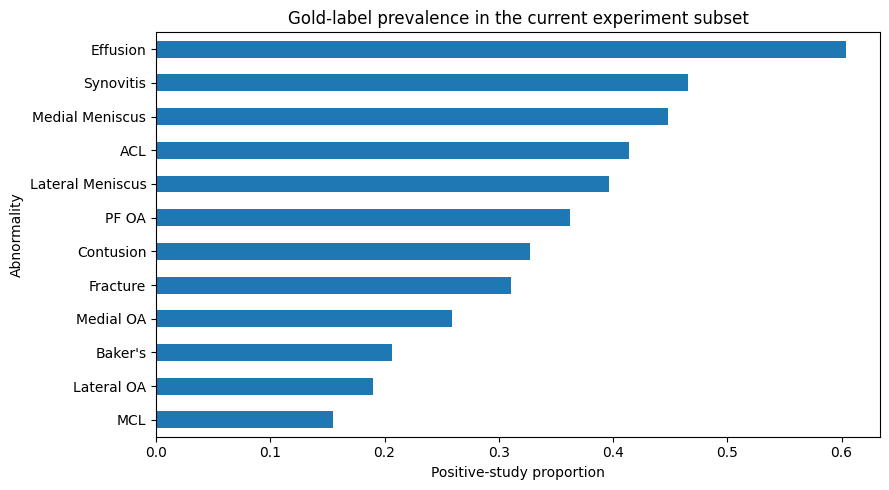


Positive counts per label:


,positive_studies
Effusion,35.0
Synovitis,27.0
Medial Meniscus,26.0
ACL,24.0
Lateral Meniscus,23.0
PF OA,21.0
Contusion,19.0
Fracture,18.0
Medial OA,15.0
Baker's,12.0


In [4]:
# ==================================================
# 04 — Gold subset + prevalence diagnostic
# ==================================================

gold_df = train.dropna(
    subset=LABEL_COLS
).copy()

print(
    "Complete gold studies:",
    len(gold_df)
)

if SMOKE_TEST:
    gold_df = gold_df.head(
        SMOKE_GOLD_LIMIT
    ).copy()

    print("\nSMOKE TEST MODE")
    print(
        "Gold studies used:",
        len(gold_df)
    )

else:
    if len(gold_df) < 50:
        raise RuntimeError(
            f"""
STOP.

Only {len(gold_df)} complete gold-labelled
studies are visible.

The full experiment is expected to use the
58-study gold subset.
"""
        )

gold_ids = set(
    gold_df[
        "StudyInstanceUID"
    ]
)

cv_gold = cv_folds[
    cv_folds[
        "StudyInstanceUID"
    ].isin(gold_ids)
].copy()

print(
    "Gold studies present in CV:",
    cv_gold[
        "StudyInstanceUID"
    ].nunique()
)

if not SMOKE_TEST and (
    cv_gold[
        "StudyInstanceUID"
    ].nunique()
    != len(gold_df)
):
    raise RuntimeError(
        "Not all gold studies have fold assignments."
    )

# Prevalence plot
gold_prevalence = (
    gold_df[LABEL_COLS]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))
gold_prevalence.plot(
    kind="barh"
)
plt.xlabel("Positive-study proportion")
plt.ylabel("Abnormality")
plt.title(
    "Gold-label prevalence in the current experiment subset"
)
plt.tight_layout()
plt.show()

print("\nPositive counts per label:")
display(
    gold_df[LABEL_COLS]
    .sum()
    .sort_values(ascending=False)
    .to_frame("positive_studies")
)


In [5]:
# ==================================================
# 05 — Coverage, schema and leakage checks
# ==================================================

covered_gold = set(
    index_2p5d[
        index_2p5d[
            "StudyInstanceUID"
        ].isin(gold_ids)
    ][
        "StudyInstanceUID"
    ].unique()
)

missing_gold = sorted(
    gold_ids - covered_gold
)

print("Gold studies:", len(gold_ids))
print(
    "Gold studies with 2.5D data:",
    len(covered_gold)
)
print(
    "Missing gold studies:",
    len(missing_gold)
)

if missing_gold:
    print("\nFirst missing IDs:")
    for sid in missing_gold[:5]:
        print(sid)

if not SMOKE_TEST and missing_gold:
    raise RuntimeError(
        f"""
STOP.

{len(missing_gold)} gold studies are missing
from the 2.5D artifact.
Regenerate Notebook 03/04 first.
"""
    )

required_cols = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "File_Path",
    "Num_Slices",
    "Prev_Slice_Index",
    "Center_Slice_Index",
    "Next_Slice_Index"
]

missing_cols = [
    c for c in required_cols
    if c not in index_2p5d.columns
]

if missing_cols:
    raise RuntimeError(
        "Missing required columns: "
        + str(missing_cols)
    )

# Reduce to the selected gold studies.
index_2p5d = index_2p5d[
    index_2p5d[
        "StudyInstanceUID"
    ].isin(gold_ids)
].copy()

print(
    "\nGold 2.5D rows:",
    len(index_2p5d)
)

# Confirm one fold per study.
fold_counts = (
    cv_folds[
        cv_folds[
            "StudyInstanceUID"
        ].isin(gold_ids)
    ]
    .groupby("StudyInstanceUID")["fold"]
    .nunique()
)

bad_fold_assignments = fold_counts[
    fold_counts > 1
]

if len(bad_fold_assignments) > 0:
    raise RuntimeError(
        "Leakage detected: at least one study "
        "has more than one fold assignment."
    )

print(
    "Study-level fold leakage check: PASSED"
)


Gold studies: 58
Gold studies with 2.5D data: 58
Missing gold studies: 0

Gold 2.5D rows: 10528
Study-level fold leakage check: PASSED


In [6]:
# ==================================================
# 06 — Attach study-level fold assignments
# ==================================================

study_info = gold_df[
    ["StudyInstanceUID"] + LABEL_COLS
].copy()

study_info = study_info.merge(
    cv_folds[
        [
            "StudyInstanceUID",
            "fold"
        ]
    ],
    on="StudyInstanceUID",
    how="left"
)

if study_info["fold"].isna().any():
    missing_fold_studies = (
        study_info.loc[
            study_info["fold"].isna(),
            "StudyInstanceUID"
        ]
        .tolist()
    )

    raise RuntimeError(
        "Some gold studies do not have a fold assignment: "
        + str(missing_fold_studies[:10])
    )

gold_df = (
    gold_df
    .drop(
        columns=["fold"],
        errors="ignore"
    )
    .merge(
        study_info[
            [
                "StudyInstanceUID",
                "fold"
            ]
        ],
        on="StudyInstanceUID",
        how="left"
    )
)

derived_cols = ["fold"] + LABEL_COLS

index_2p5d = index_2p5d.drop(
    columns=[
        c for c in derived_cols
        if c in index_2p5d.columns
    ],
    errors="ignore"
)

index_2p5d = index_2p5d.merge(
    study_info[
        [
            "StudyInstanceUID",
            "fold"
        ] + LABEL_COLS
    ],
    on="StudyInstanceUID",
    how="left"
)

print(
    "gold_df contains fold:",
    "fold" in gold_df.columns
)

print(
    "index_2p5d contains fold:",
    "fold" in index_2p5d.columns
)

print("\nFold distribution:")
print(
    study_info[
        "fold"
    ].value_counts().sort_index()
)


gold_df contains fold: True
index_2p5d contains fold: True

Fold distribution:
fold
0    12
1    12
2    12
3    11
4    11
Name: count, dtype: int64


In [7]:
# ==================================================
# 07 — Robust processed-volume path resolution
# ==================================================

def resolve_volume_path(original_path):

    original_path = str(
        original_path
    )

    # Case 1: path already valid.
    if os.path.exists(
        original_path
    ):
        return original_path

    normalized = original_path.replace(
        "\\",
        "/"
    )

    marker = "/processed_data/"

    if marker in normalized:
        suffix = normalized.split(
            marker,
            1
        )[1]

        for processed_root in processed_roots:

            candidate = os.path.join(
                processed_root,
                suffix
            )

            if os.path.exists(
                candidate
            ):
                return candidate

    # Fallback by basename.
    basename = os.path.basename(
        normalized
    )

    for processed_root in processed_roots:

        matches = glob.glob(
            os.path.join(
                processed_root,
                "**",
                basename
            ),
            recursive=True
        )

        if matches:
            return sorted(
                matches
            )[0]

    raise FileNotFoundError(
        "Processed volume could not be resolved.\n\n"
        f"Original path:\n{original_path}\n\n"
        "Mounted processed_data directories:\n"
        + (
            "\n".join(processed_roots)
            if processed_roots
            else "NONE"
        )
        + "\n\n"
        "Attach the Notebook 03 preprocessing output."
    )


test_resolved = resolve_volume_path(
    index_2p5d[
        "File_Path"
    ].iloc[0]
)

print(
    "Resolved volume:",
    test_resolved
)

print(
    "Exists:",
    os.path.exists(
        test_resolved
    )
)


Resolved volume: /kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282.npy
Exists: True


## 3. 2.5D input and ViT-S/16

Each 2.5D instance is converted to a `3 × 224 × 224` tensor using three neighbouring MRI slices. The three slices are treated as channels, analogous to RGB, so the pretrained ViT can be used without changing its patch-embedding input dimensionality.

At the study level, the ViT produces one prediction per 2.5D instance and the instance logits are mean-pooled before applying the multi-label loss.


In [8]:
# ==================================================
# 08 — Dataset and 2.5D image loading
# ==================================================

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(
    3, 1, 1
)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(
    3, 1, 1
)


@lru_cache(maxsize=8)
def load_volume(path):
    return np.load(
        path,
        mmap_mode="r"
    )


def load_2p5d_sample(row):

    path = resolve_volume_path(
        row["File_Path"]
    )

    volume = load_volume(
        path
    )

    p = int(
        row["Prev_Slice_Index"]
    )

    c = int(
        row["Center_Slice_Index"]
    )

    n = int(
        row["Next_Slice_Index"]
    )

    x = np.stack(
        [
            volume[p],
            volume[c],
            volume[n]
        ],
        axis=0
    ).astype(
        np.float32
    )

    if x.shape[1:] != (
        IMAGE_SIZE,
        IMAGE_SIZE
    ):
        raise ValueError(
            f"Unexpected 2.5D shape: {x.shape}"
        )

    x = torch.from_numpy(x)

    x = (
        x - IMAGENET_MEAN
    ) / IMAGENET_STD

    return x


class StudyDataset(Dataset):

    def __init__(
        self,
        index_df,
        study_df,
        max_instances=None,
        sampling_seed=42
    ):

        self.index_df = (
            index_df.reset_index(drop=True)
        )

        self.study_df = (
            study_df.reset_index(drop=True)
        )

        self.max_instances = (
            max_instances
        )

        self.sampling_seed = (
            sampling_seed
        )

        self.study_ids = (
            self.study_df[
                "StudyInstanceUID"
            ].tolist()
        )

        self.grouped = {}

        for study_id in self.study_ids:
            self.grouped[
                study_id
            ] = self.index_df[
                self.index_df[
                    "StudyInstanceUID"
                ] == study_id
            ].reset_index(
                drop=True
            )

    def __len__(self):
        return len(
            self.study_ids
        )

    def __getitem__(self, idx):

        study_id = (
            self.study_ids[idx]
        )

        rows = self.grouped[
            study_id
        ].copy()

        if (
            self.max_instances is not None
            and len(rows) > self.max_instances
        ):
            rows = rows.sample(
                n=self.max_instances,
                random_state=(
                    self.sampling_seed
                    + idx
                )
            )

        study_row = self.study_df[
            self.study_df[
                "StudyInstanceUID"
            ] == study_id
        ].iloc[0]

        labels = (
            study_row[
                LABEL_COLS
            ]
            .values
            .astype(np.float32)
        )

        return (
            rows.to_dict("records"),
            torch.tensor(
                labels,
                dtype=torch.float32
            ),
            study_id
        )


def study_collate(batch):
    return batch[0]

print("StudyDataset ready.")


StudyDataset ready.


In [9]:
# ==================================================
# 09 — Build ViT-S/16
# ==================================================

def build_model():

    model = timm.create_model(
        MODEL_NAME,
        pretrained=PRETRAINED,
        num_classes=NUM_CLASSES
    )

    if FREEZE_BACKBONE:

        for name, parameter in model.named_parameters():

            # Keep only the classification head trainable.
            parameter.requires_grad = (
                name.startswith("head.")
            )

        # Keep frozen transformer blocks deterministic.
        model.eval()

        if hasattr(model, "head"):
            model.head.train()

    return model.to(
        DEVICE
    )


model = build_model()

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Model:",
    MODEL_NAME
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: vit_small_patch16_224
Total parameters: 21,670,284
Trainable parameters: 4,620


In [10]:
# ==================================================
# 10 — Forward-pass sanity check
# ==================================================

sample_rows = StudyDataset(
    index_2p5d,
    gold_df,
    max_instances=1,
    sampling_seed=SEED
)[0][0]

sample_x = load_2p5d_sample(
    sample_rows[0]
)

print(
    "Single 2.5D tensor shape:",
    tuple(sample_x.shape)
)

with torch.no_grad():

    sample_logits = model(
        sample_x.unsqueeze(0).to(
            DEVICE
        )
    )

print(
    "ViT output shape:",
    tuple(sample_logits.shape)
)

if tuple(sample_x.shape) != (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
):
    raise RuntimeError(
        "Unexpected input tensor shape."
    )

if tuple(sample_logits.shape) != (
    1,
    NUM_CLASSES
):
    raise RuntimeError(
        "Unexpected model output shape."
    )

print(
    "Forward-pass sanity check: PASSED"
)


Single 2.5D tensor shape: (3, 224, 224)
ViT output shape: (1, 12)
Forward-pass sanity check: PASSED


In [11]:
# ==================================================
# 11 — Study-level forward pass + class weights
# ==================================================

def study_forward(
    model,
    rows
):

    tensors = []

    for row in rows:

        tensors.append(
            load_2p5d_sample(
                row
            )
        )

    x = torch.stack(
        tensors
    )

    logits_chunks = []

    for start in range(
        0,
        len(x),
        INSTANCE_BATCH_SIZE
    ):

        xb = x[
            start:
            start + INSTANCE_BATCH_SIZE
        ].to(
            DEVICE,
            non_blocking=True
        )

        logits = model(
            xb
        )

        logits_chunks.append(
            logits
        )

    all_logits = torch.cat(
        logits_chunks,
        dim=0
    )

    return all_logits.mean(
        dim=0
    )


def create_pos_weight(
    train_studies
):

    y = train_studies[
        LABEL_COLS
    ].values.astype(
        np.float32
    )

    positives = y.sum(
        axis=0
    )

    negatives = (
        len(y) - positives
    )

    weights = np.ones(
        NUM_CLASSES,
        dtype=np.float32
    )

    valid = positives > 0

    weights[valid] = (
        negatives[valid]
        /
        positives[valid]
    )

    weights = np.clip(
        weights,
        1.0,
        20.0
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE
    )

print(
    "Study-level pooling and class-weight utilities ready."
)


Study-level pooling and class-weight utilities ready.


## 4. Training and common evaluation protocol

The loss is **weighted binary cross-entropy with logits**, because the task has twelve independent binary targets and strong class imbalance.

For each CV fold, validation remains completely study-held-out. The best checkpoint is selected by validation loss rather than ROC-AUC, because rare labels may be absent from an individual fold.

The metrics and threshold below are kept identical to Notebook 07 so the eventual model-comparison table is fair.


In [12]:
# ==================================================
# 12 — Common evaluation utilities
# ==================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    accuracy_score,
    roc_curve,
    precision_recall_curve
)


def compute_per_class_metrics(
    y_true,
    y_prob,
    threshold=CLASSIFICATION_THRESHOLD
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    rows = []

    for j, label in enumerate(
        LABEL_COLS
    ):

        true_j = y_true[:, j].astype(int)
        prob_j = y_prob[:, j]
        pred_j = y_pred[:, j]

        tp = int(
            np.sum(
                (true_j == 1)
                &
                (pred_j == 1)
            )
        )

        tn = int(
            np.sum(
                (true_j == 0)
                &
                (pred_j == 0)
            )
        )

        fp = int(
            np.sum(
                (true_j == 0)
                &
                (pred_j == 1)
            )
        )

        fn = int(
            np.sum(
                (true_j == 1)
                &
                (pred_j == 0)
            )
        )

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else np.nan
        )

        recall = (
            tp / (tp + fn)
            if tp + fn > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if tn + fp > 0
            else np.nan
        )

        f1 = (
            2 * precision * recall
            /
            (precision + recall)
            if (
                np.isfinite(precision)
                and np.isfinite(recall)
                and precision + recall > 0
            )
            else 0.0
        )

        has_both_classes = (
            len(
                np.unique(true_j)
            ) == 2
        )

        auc = (
            roc_auc_score(
                true_j,
                prob_j
            )
            if has_both_classes
            else np.nan
        )

        pr_auc = (
            average_precision_score(
                true_j,
                prob_j
            )
            if has_both_classes
            else np.nan
        )

        rows.append({
            "label": label,
            "prevalence": float(
                true_j.mean()
            ),
            "positive_count": int(
                true_j.sum()
            ),
            "precision": precision,
            "recall": recall,
            "sensitivity": recall,
            "specificity": specificity,
            "f1": f1,
            "roc_auc": auc,
            "pr_auc": pr_auc,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn
        })

    return pd.DataFrame(
        rows
    )


def compute_metrics(
    y_true,
    y_prob,
    threshold=CLASSIFICATION_THRESHOLD
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    per_class = compute_per_class_metrics(
        y_true,
        y_prob,
        threshold
    )

    valid_auc = (
        per_class["roc_auc"]
        .dropna()
    )

    valid_pr = (
        per_class["pr_auc"]
        .dropna()
    )

    return {
        "macro_auc": (
            valid_auc.mean()
            if len(valid_auc)
            else np.nan
        ),
        "macro_pr_auc": (
            valid_pr.mean()
            if len(valid_pr)
            else np.nan
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_specificity": (
            per_class[
                "specificity"
            ].mean()
        ),
        "micro_f1": f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        ),
        "hamming_loss": hamming_loss(
            y_true,
            y_pred
        ),
        "subset_accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "valid_auc_classes": int(
            len(valid_auc)
        ),
        "valid_pr_auc_classes": int(
            len(valid_pr)
        )
    }


print(
    "Evaluation utilities ready."
)


Evaluation utilities ready.


In [13]:
# ==================================================
# 13 — Train one fold
# ==================================================

def train_fold(
    fold
):

    print("=" * 70)
    print(
        f"ViT-S/16 | FOLD {fold}"
    )
    print("=" * 70)

    train_studies = gold_df[
        gold_df["fold"] != fold
    ].copy()

    val_studies = gold_df[
        gold_df["fold"] == fold
    ].copy()

    train_index = index_2p5d[
        index_2p5d[
            "StudyInstanceUID"
        ].isin(
            train_studies[
                "StudyInstanceUID"
            ]
        )
    ].copy()

    val_index = index_2p5d[
        index_2p5d[
            "StudyInstanceUID"
        ].isin(
            val_studies[
                "StudyInstanceUID"
            ]
        )
    ].copy()

    print(
        "Train studies:",
        len(train_studies)
    )

    print(
        "Validation studies:",
        len(val_studies)
    )

    train_ds = StudyDataset(
        train_index,
        train_studies,
        MAX_TRAIN_INSTANCES,
        SEED + fold
    )

    val_ds = StudyDataset(
        val_index,
        val_studies,
        MAX_VAL_INSTANCES,
        SEED + 100 + fold
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=STUDY_BATCH_SIZE,
        shuffle=True,
        collate_fn=study_collate,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        collate_fn=study_collate,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = build_model()

    pos_weight = create_pos_weight(
        train_studies
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        [
            p for p in model.parameters()
            if p.requires_grad
        ],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    history = []

    best_val_loss = np.inf
    best_state = None

    for epoch in range(
        EPOCHS
    ):

        model.train()

        if FREEZE_BACKBONE:
            model.eval()

            if hasattr(
                model,
                "head"
            ):
                model.head.train()

        running_loss = 0.0

        for rows, y, study_id in train_loader:

            y = y.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):

                study_logits = study_forward(
                    model,
                    rows
                )

                loss = criterion(
                    study_logits.unsqueeze(0),
                    y.unsqueeze(0)
                )

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            running_loss += (
                loss.item()
            )

        # -------------------------------
        # Validation
        # -------------------------------

        model.eval()

        val_loss_total = 0.0

        truths = []
        probs = []
        ids = []

        with torch.no_grad():

            for rows, y, study_id in val_loader:

                study_logits = study_forward(
                    model,
                    rows
                )

                loss = criterion(
                    study_logits.unsqueeze(0),
                    y.to(DEVICE).unsqueeze(0)
                )

                val_loss_total += (
                    loss.item()
                )

                study_prob = torch.sigmoid(
                    study_logits
                ).cpu().numpy()

                truths.append(
                    y.numpy()
                )

                probs.append(
                    study_prob
                )

                ids.append(
                    study_id
                )

        y_true = np.vstack(
            truths
        )

        y_prob = np.vstack(
            probs
        )

        metrics = compute_metrics(
            y_true,
            y_prob
        )

        train_loss = (
            running_loss
            /
            max(
                len(train_loader),
                1
            )
        )

        val_loss = (
            val_loss_total
            /
            max(
                len(val_loader),
                1
            )
        )

        history.append({
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **metrics
        })

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Macro F1={metrics['macro_f1']:.4f} | "
            f"Valid AUC={metrics['valid_auc_classes']}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = {
                k: v.cpu().clone()
                for k, v
                in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    # -----------------------------------
    # Final validation using best model
    # -----------------------------------

    model.eval()

    truths = []
    probs = []
    ids = []

    with torch.no_grad():

        for rows, y, study_id in val_loader:

            study_logits = study_forward(
                model,
                rows
            )

            study_prob = torch.sigmoid(
                study_logits
            ).cpu().numpy()

            truths.append(
                y.numpy()
            )

            probs.append(
                study_prob
            )

            ids.append(
                study_id
            )

    y_true = np.vstack(
        truths
    )

    y_prob = np.vstack(
        probs
    )

    final_metrics = compute_metrics(
        y_true,
        y_prob
    )

    checkpoint_path = (
        f"/kaggle/working/"
        f"vit_s16_fold_{fold}.pth"
    )

    torch.save(
        model.state_dict(),
        checkpoint_path
    )

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        f"/kaggle/working/"
        f"vit_s16_history_fold_{fold}.csv",
        index=False
    )

    prediction_rows = []

    for i, sid in enumerate(ids):

        row = {
            "StudyInstanceUID": sid,
            "fold": fold
        }

        for j, label in enumerate(
            LABEL_COLS
        ):

            row[
                f"{label}_true"
            ] = y_true[i, j]

            row[
                f"{label}_prob"
            ] = y_prob[i, j]

        prediction_rows.append(
            row
        )

    pred_df = pd.DataFrame(
        prediction_rows
    )

    pred_df.to_csv(
        f"/kaggle/working/"
        f"vit_s16_predictions_fold_{fold}.csv",
        index=False
    )

    print("\nBest-model validation:")
    print(final_metrics)
    print(
        "\nCheckpoint:",
        checkpoint_path
    )

    return (
        final_metrics,
        pred_df,
        history_df
    )


In [14]:
# ==================================================
# 14 — Run folds and collect OOF predictions
# ==================================================

fold_results = []
all_predictions = []
all_histories = []

RUN_FOLDS = (
    1
    if SMOKE_TEST
    else N_FOLDS
)

for fold in range(
    RUN_FOLDS
):

    metrics, pred_df, history_df = train_fold(
        fold
    )

    fold_results.append({
        "fold": fold,
        **metrics
    })

    all_predictions.append(
        pred_df
    )

    all_histories.append(
        history_df
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(
    "\nCompleted folds:",
    RUN_FOLDS
)


ViT-S/16 | FOLD 0
Train studies: 46
Validation studies: 12
Epoch 1/3 | Train Loss=1.0005 | Val Loss=0.9655 | Macro F1=0.1141 | Valid AUC=10
Epoch 2/3 | Train Loss=0.9361 | Val Loss=0.9598 | Macro F1=0.1518 | Valid AUC=10
Epoch 3/3 | Train Loss=0.9359 | Val Loss=0.9595 | Macro F1=0.1447 | Valid AUC=10

Best-model validation:
{'macro_auc': np.float64(0.4969312169312169), 'macro_pr_auc': np.float64(0.4194552669552669), 'macro_precision': 0.13888888888888887, 'macro_recall': 0.16805555555555554, 'macro_f1': 0.14468211527035058, 'macro_specificity': np.float64(0.7283730158730158), 'micro_f1': 0.28205128205128205, 'hamming_loss': 0.3888888888888889, 'subset_accuracy': 0.0, 'valid_auc_classes': 10, 'valid_pr_auc_classes': 10}

Checkpoint: /kaggle/working/vit_s16_fold_0.pth
ViT-S/16 | FOLD 1
Train studies: 46
Validation studies: 12
Epoch 1/3 | Train Loss=1.1233 | Val Loss=1.2962 | Macro F1=0.1426 | Valid AUC=11
Epoch 2/3 | Train Loss=0.9875 | Val Loss=1.1684 | Macro F1=0.2505 | Valid AUC=11
Ep

In [15]:
# ==================================================
# 15 — OOF summary and comparison-ready results
# ==================================================

results_df = pd.DataFrame(
    fold_results
)

all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

all_history_df = pd.concat(
    all_histories,
    ignore_index=True
)

duplicate_oof = (
    all_predictions_df[
        "StudyInstanceUID"
    ]
    .duplicated()
    .sum()
)

if duplicate_oof > 0:
    raise RuntimeError(
        f"Found {duplicate_oof} duplicate OOF studies."
    )

results_path = (
    "/kaggle/working/"
    "vit_s16_fold_results.csv"
)

oof_path = (
    "/kaggle/working/"
    "vit_s16_oof_predictions.csv"
)

history_path = (
    "/kaggle/working/"
    "vit_s16_all_history.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

all_predictions_df.to_csv(
    oof_path,
    index=False
)

all_history_df.to_csv(
    history_path,
    index=False
)

summary_cols = [
    "macro_auc",
    "macro_pr_auc",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "macro_specificity",
    "micro_f1",
    "hamming_loss",
    "subset_accuracy"
]

summary_rows = []

for metric in summary_cols:

    summary_rows.append({
        "metric": metric,
        "mean": results_df[
            metric
        ].mean(),
        "std": results_df[
            metric
        ].std(
            ddof=0
        )
    })

metric_summary_df = pd.DataFrame(
    summary_rows
)

metric_summary_df.to_csv(
    "/kaggle/working/"
    "vit_s16_metric_summary.csv",
    index=False
)

comparison_row = {
    "model": "ViT-S/16"
}

for metric in summary_cols:

    comparison_row[
        metric
    ] = results_df[
        metric
    ].mean()

comparison_df = pd.DataFrame(
    [comparison_row]
)

comparison_df.to_csv(
    "/kaggle/working/"
    "vit_s16_comparison_row.csv",
    index=False
)

print("Fold results:")
display(results_df)

print("\nMean ± SD:")
display(
    metric_summary_df
)


Fold results:


,fold,macro_auc,macro_pr_auc,macro_precision,macro_recall,macro_f1,macro_specificity,micro_f1,hamming_loss,subset_accuracy,valid_auc_classes,valid_pr_auc_classes
0,0,0.496931,0.419455,0.138889,0.168056,0.144682,0.728373,0.282051,0.388889,0.0,10,10
1,1,0.586797,0.549203,0.236688,0.305556,0.246726,0.713955,0.421053,0.381944,0.0,11,11
2,2,0.640655,0.582545,0.250812,0.301389,0.255148,0.749729,0.466667,0.333333,0.0,12,12
3,3,0.523148,0.521300,0.289286,0.275000,0.264675,0.775397,0.405063,0.356061,0.0,12,12
4,4,0.547917,0.595697,0.534722,0.355159,0.368927,0.783036,0.477273,0.348485,0.0,12,12



Mean ± SD:


,metric,mean,std
0,macro_auc,0.559089,0.050400
1,macro_pr_auc,0.533640,0.062730
2,macro_precision,0.290079,0.131986
3,macro_recall,0.281032,0.062146
4,macro_f1,0.256032,0.071142
5,macro_specificity,0.750098,0.026470
6,micro_f1,0.410421,0.069647
7,hamming_loss,0.361742,0.020785
8,subset_accuracy,0.000000,0.000000


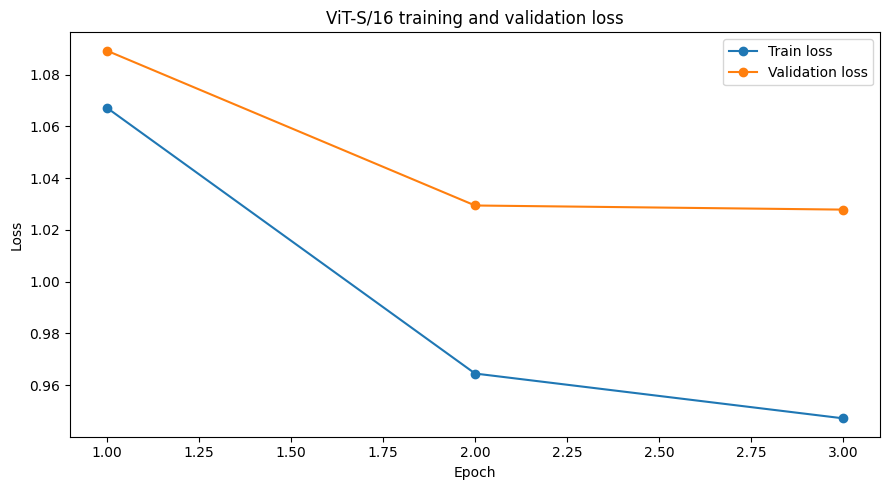

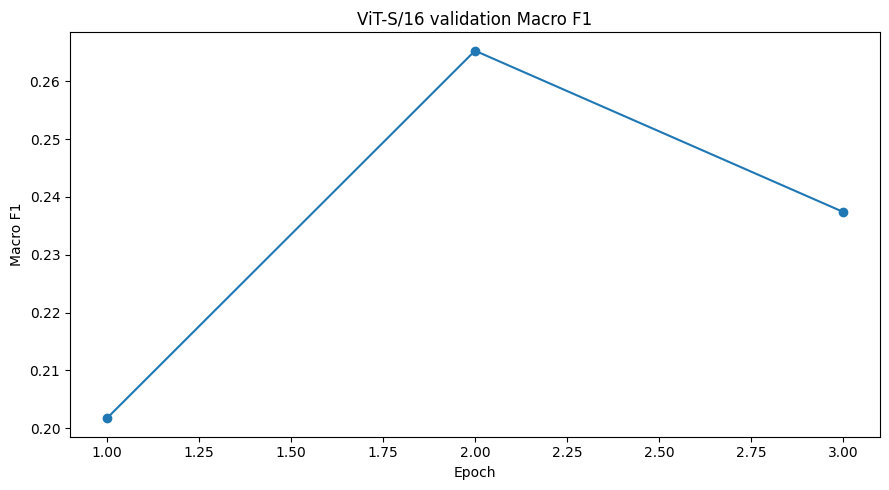

In [16]:
# ==================================================
# 16 — Training curves
# ==================================================

if len(all_history_df) > 0:

    curve_df = (
        all_history_df
        .groupby("epoch")[
            [
                "train_loss",
                "val_loss",
                "macro_f1"
            ]
        ]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        curve_df["epoch"],
        curve_df["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        curve_df["epoch"],
        curve_df["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ViT-S/16 training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))

    plt.plot(
        curve_df["epoch"],
        curve_df["macro_f1"],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("ViT-S/16 validation Macro F1")
    plt.tight_layout()
    plt.show()


OOF metrics:
{'macro_auc': np.float64(0.5168080340816065), 'macro_pr_auc': np.float64(0.40327019492494043), 'macro_precision': 0.3570579414939172, 'macro_recall': 0.2907152508268069, 'macro_f1': 0.2820490025231967, 'macro_specificity': np.float64(0.7466811116512769), 'micro_f1': 0.413953488372093, 'hamming_loss': 0.3620689655172414, 'subset_accuracy': 0.0, 'valid_auc_classes': 12, 'valid_pr_auc_classes': 12}


,label,positive_count,roc_auc,pr_auc,precision,recall,specificity,f1
0,ACL,24,0.549020,0.472809,0.463415,0.791667,0.352941,0.584615
1,MCL,9,0.206349,0.106013,0.000000,0.000000,0.979592,0.000000
2,Medial Meniscus,26,0.701923,0.677429,0.727273,0.615385,0.812500,0.666667
3,Lateral Meniscus,23,0.424845,0.358264,0.250000,0.043478,0.914286,0.074074
4,Medial OA,15,0.550388,0.300180,0.222222,0.133333,0.837209,0.166667
5,Lateral OA,11,0.597679,0.314886,NaN,0.000000,1.000000,0.000000
6,PF OA,21,0.594595,0.524966,0.437500,0.333333,0.756757,0.378378
7,Effusion,35,0.647205,0.705929,0.620000,0.885714,0.173913,0.729412
8,Synovitis,27,0.567503,0.546028,0.600000,0.111111,0.935484,0.187500
9,Baker's,12,0.541667,0.247701,0.500000,0.083333,0.978261,0.142857


<Figure size 1100x600 with 0 Axes>

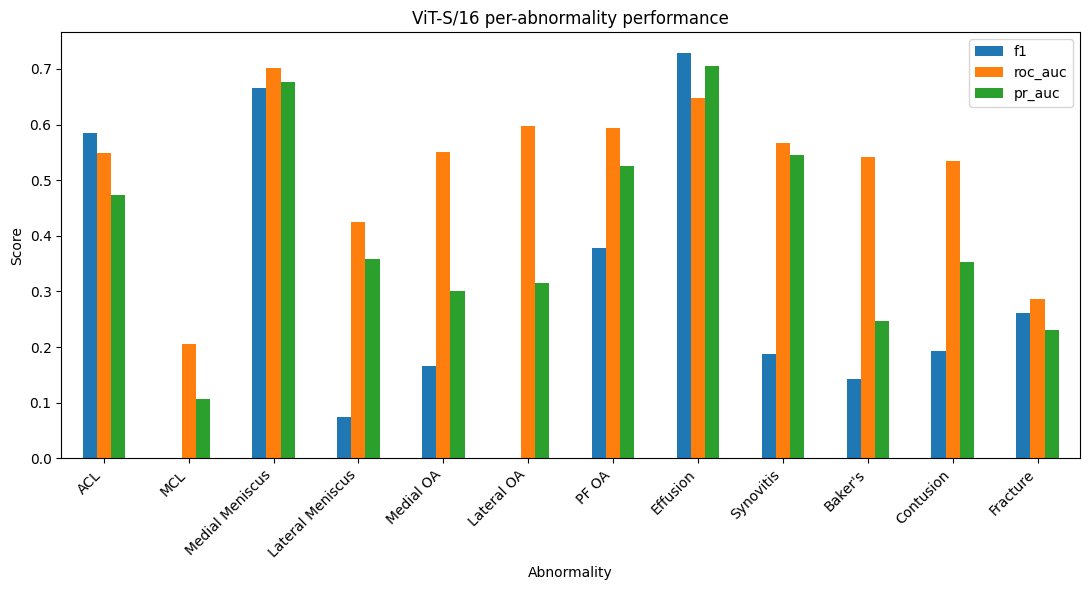

In [17]:
# ==================================================
# 17 — OOF per-abnormality metrics
# ==================================================

oof_true = np.column_stack(
    [
        all_predictions_df[
            f"{label}_true"
        ].values
        for label in LABEL_COLS
    ]
)

oof_prob = np.column_stack(
    [
        all_predictions_df[
            f"{label}_prob"
        ].values
        for label in LABEL_COLS
    ]
)

oof_metrics = compute_metrics(
    oof_true,
    oof_prob
)

per_class_df = compute_per_class_metrics(
    oof_true,
    oof_prob
)

per_class_df.to_csv(
    "/kaggle/working/"
    "vit_s16_oof_per_class_metrics.csv",
    index=False
)

print("OOF metrics:")
print(oof_metrics)

display(
    per_class_df[
        [
            "label",
            "positive_count",
            "roc_auc",
            "pr_auc",
            "precision",
            "recall",
            "specificity",
            "f1"
        ]
    ]
)

plot_df = (
    per_class_df
    .set_index("label")[
        [
            "f1",
            "roc_auc",
            "pr_auc"
        ]
    ]
)

plt.figure(
    figsize=(11, 6)
)

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")
plt.xlabel("Abnormality")
plt.title(
    "ViT-S/16 per-abnormality performance"
)
plt.xticks(
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()


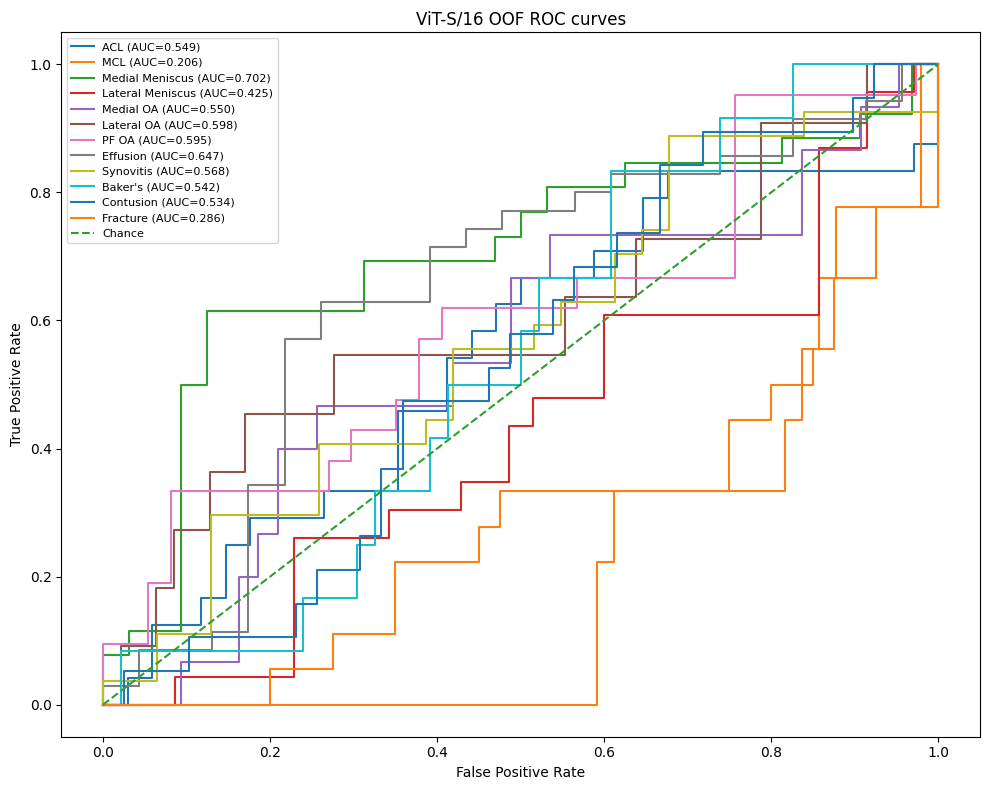

In [18]:
# ==================================================
# 18 — OOF ROC curves
# ==================================================

plt.figure(
    figsize=(10, 8)
)

plotted = 0

for j, label in enumerate(
    LABEL_COLS
):

    true_j = oof_true[:, j]

    if len(
        np.unique(true_j)
    ) != 2:
        continue

    prob_j = oof_prob[:, j]

    fpr, tpr, _ = roc_curve(
        true_j,
        prob_j
    )

    auc = roc_auc_score(
        true_j,
        prob_j
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc:.3f})"
    )

    plotted += 1

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ViT-S/16 OOF ROC curves"
)

if plotted <= 12:
    plt.legend(
        fontsize=8
    )

plt.tight_layout()
plt.show()


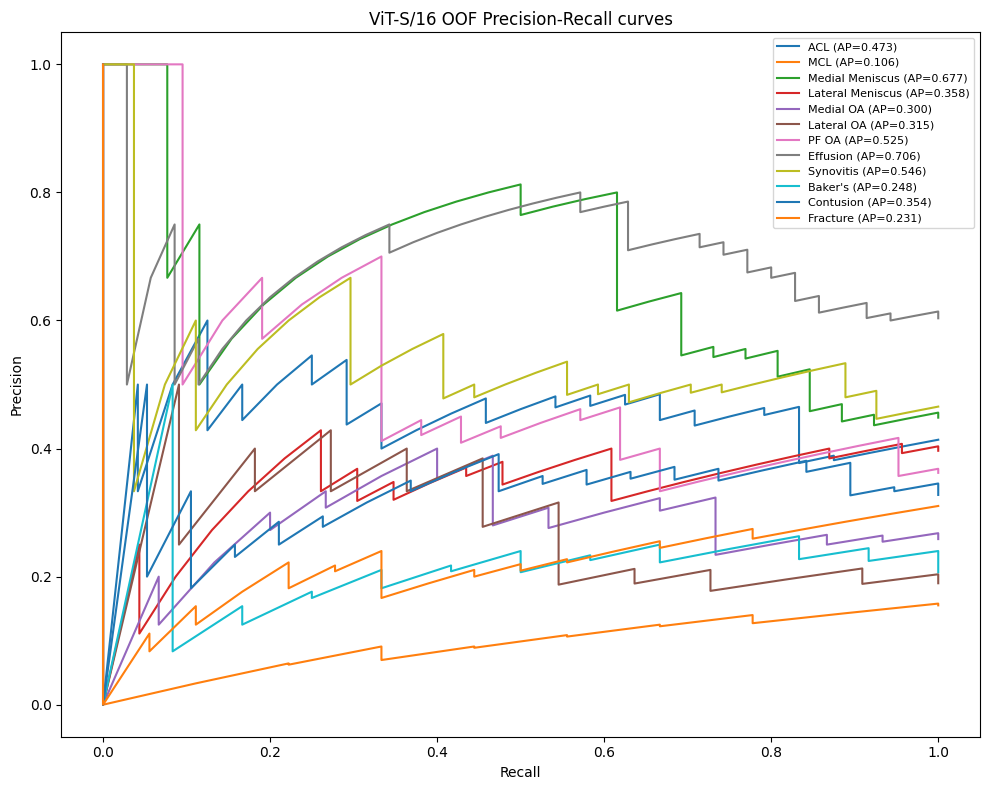

In [19]:
# ==================================================
# 19 — OOF Precision-Recall curves
# ==================================================

plt.figure(
    figsize=(10, 8)
)

plotted = 0

for j, label in enumerate(
    LABEL_COLS
):

    true_j = oof_true[:, j]

    if len(
        np.unique(true_j)
    ) != 2:
        continue

    prob_j = oof_prob[:, j]

    precision, recall, _ = precision_recall_curve(
        true_j,
        prob_j
    )

    ap = average_precision_score(
        true_j,
        prob_j
    )

    plt.plot(
        recall,
        precision,
        label=f"{label} (AP={ap:.3f})"
    )

    plotted += 1

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "ViT-S/16 OOF Precision-Recall curves"
)

if plotted <= 12:
    plt.legend(
        fontsize=8
    )

plt.tight_layout()
plt.show()


In [20]:
# ==================================================
# 20 — Study-level error analysis
# ==================================================

oof_pred = (
    oof_prob >= CLASSIFICATION_THRESHOLD
).astype(int)

study_error_rows = []

for i in range(
    len(all_predictions_df)
):

    true_i = oof_true[i]
    pred_i = oof_pred[i]

    incorrect = np.where(
        true_i != pred_i
    )[0]

    study_error_rows.append({
        "StudyInstanceUID":
            all_predictions_df.iloc[i][
                "StudyInstanceUID"
            ],
        "fold":
            all_predictions_df.iloc[i][
                "fold"
            ],
        "num_label_errors":
            int(len(incorrect)),
        "false_positive_labels":
            ", ".join(
                LABEL_COLS[j]
                for j in incorrect
                if (
                    pred_i[j] == 1
                    and true_i[j] == 0
                )
            ),
        "false_negative_labels":
            ", ".join(
                LABEL_COLS[j]
                for j in incorrect
                if (
                    pred_i[j] == 0
                    and true_i[j] == 1
                )
            )
    })

error_df = (
    pd.DataFrame(
        study_error_rows
    )
    .sort_values(
        "num_label_errors",
        ascending=False
    )
)

display(
    error_df.head(10)
)

error_df.to_csv(
    "/kaggle/working/"
    "vit_s16_oof_error_analysis.csv",
    index=False
)

print(
    "Studies with at least one label error:",
    int(
        (
            error_df[
                "num_label_errors"
            ] > 0
        ).sum()
    )
)

print(
    "Mean label errors per study:",
    error_df[
        "num_label_errors"
    ].mean()
)


,StudyInstanceUID,fold,num_label_errors,false_positive_labels,false_negative_labels
4,1.2.826.0.1.3680043.8.498.12801308844398614687...,0,8,Fracture,"Medial Meniscus, Lateral Meniscus, Medial OA, ..."
5,1.2.826.0.1.3680043.8.498.28925345859498351203...,0,8,"ACL, Effusion, Fracture","Medial Meniscus, Lateral Meniscus, Medial OA, ..."
24,1.2.826.0.1.3680043.8.498.11915937982684988073...,2,8,"ACL, Medial Meniscus, Contusion","Lateral Meniscus, Lateral OA, PF OA, Synovitis..."
15,1.2.826.0.1.3680043.8.498.15593638897292057356...,1,8,"ACL, MCL, Effusion, Fracture","Lateral Meniscus, Medial OA, Lateral OA, Synov..."
43,1.2.826.0.1.3680043.8.498.65708905118633339771...,3,8,ACL,"Medial Meniscus, Lateral Meniscus, Lateral OA,..."
38,1.2.826.0.1.3680043.8.498.22109739962224309418...,3,7,"ACL, Effusion, Contusion","Lateral Meniscus, Medial OA, Lateral OA, Baker's"
23,1.2.826.0.1.3680043.8.498.88077418639301174409...,1,6,"Contusion, Fracture","Lateral Meniscus, Medial OA, Lateral OA, Baker's"
36,1.2.826.0.1.3680043.8.498.10170898615867673028...,3,6,"ACL, Effusion, Fracture","Lateral Meniscus, PF OA, Synovitis"
10,1.2.826.0.1.3680043.8.498.73926443729786165628...,0,6,"ACL, Baker's, Contusion, Fracture","PF OA, Synovitis"
18,1.2.826.0.1.3680043.8.498.39500553372517290823...,1,6,"ACL, Fracture","Lateral Meniscus, Lateral OA, PF OA, Synovitis"


Studies with at least one label error: 58
Mean label errors per study: 4.344827586206897


## 6. Reproducibility outputs

The notebook saves the fold metrics, OOF predictions, training history, per-abnormality metrics, error analysis and a one-row summary that can later be combined with the corresponding outputs from Notebook 07 and Notebook 09/12.

Do not report smoke-test metrics as final research results.


In [21]:
# ==================================================
# 21 — Final artifact checklist
# ==================================================

expected_outputs = [
    "vit_s16_fold_results.csv",
    "vit_s16_oof_predictions.csv",
    "vit_s16_metric_summary.csv",
    "vit_s16_comparison_row.csv",
    "vit_s16_all_history.csv",
    "vit_s16_oof_per_class_metrics.csv",
    "vit_s16_oof_error_analysis.csv"
]

for fold in range(
    RUN_FOLDS
):
    expected_outputs.append(
        f"vit_s16_fold_{fold}.pth"
    )
    expected_outputs.append(
        f"vit_s16_history_fold_{fold}.csv"
    )
    expected_outputs.append(
        f"vit_s16_predictions_fold_{fold}.csv"
    )

print(
    "Generated artifact checklist:"
)

for name in expected_outputs:

    path = os.path.join(
        "/kaggle/working",
        name
    )

    status = (
        "OK  "
        if os.path.exists(path)
        else "MISS"
    )

    print(
        f"{status} {name}"
    )


Generated artifact checklist:
OK   vit_s16_fold_results.csv
OK   vit_s16_oof_predictions.csv
OK   vit_s16_metric_summary.csv
OK   vit_s16_comparison_row.csv
OK   vit_s16_all_history.csv
OK   vit_s16_oof_per_class_metrics.csv
OK   vit_s16_oof_error_analysis.csv
OK   vit_s16_fold_0.pth
OK   vit_s16_history_fold_0.csv
OK   vit_s16_predictions_fold_0.csv
OK   vit_s16_fold_1.pth
OK   vit_s16_history_fold_1.csv
OK   vit_s16_predictions_fold_1.csv
OK   vit_s16_fold_2.pth
OK   vit_s16_history_fold_2.csv
OK   vit_s16_predictions_fold_2.csv
OK   vit_s16_fold_3.pth
OK   vit_s16_history_fold_3.csv
OK   vit_s16_predictions_fold_3.csv
OK   vit_s16_fold_4.pth
OK   vit_s16_history_fold_4.csv
OK   vit_s16_predictions_fold_4.csv
